# Telecom Churn Prediction - Starter Notebook

**Author:** Abhijit Ray

# 0. Problem statement

In the telecom industry, customers are able to choose from multiple service providers and actively switch from one operator to another. In this highly competitive market, the telecommunications industry experiences an average of 15-25% annual churn rate. Given the fact that it costs 5-10 times more to acquire a new customer than to retain an existing one, customer retention has now become even more important than customer acquisition.

For many incumbent operators, retaining high profitable customers is the number one business
goal. To reduce customer churn, telecom companies need to predict which customers are at high risk of churn. In this project, you will analyze customer-level data of a leading telecom firm, build predictive models to identify customers at high risk of churn, and identify the main indicators of churn.

In this competition, your goal is *to build a machine learning model that is able to predict churning customers based on the features provided for their usage.*

**Customer behaviour during churn:**

Customers usually do not decide to switch to another competitor instantly, but rather over a
period of time (this is especially applicable to high-value customers). In churn prediction, we
assume that there are three phases of customer lifecycle :

1. <u>The ‘good’ phase:</u> In this phase, the customer is happy with the service and behaves as usual.

2. <u>The ‘action’ phase:</u> The customer experience starts to sore in this phase, for e.g. he/she gets a compelling offer from a competitor, faces unjust charges, becomes unhappy with service quality etc. In this phase, the customer usually shows different behaviour than the ‘good’ months. It is crucial to identify high-churn-risk customers in this phase, since some corrective actions can be taken at this point (such as matching the competitor’s offer/improving the service quality etc.)

3. <u>The ‘churn’ phase:</u> In this phase, the customer is said to have churned. In this case, since you are working over a four-month window, the first two months are the ‘good’ phase, the third month is the ‘action’ phase, while the fourth month (September) is the ‘churn’ phase.

# 1. Loading dependencies & datasets

Lets start by loading our dependencies. We can keep adding any imports to this cell block, as we write mode and mode code.

In [435]:
#Data Structures
import pandas as pd
import numpy as np
import re
import os

### For installing missingno library, type this command in terminal
#pip install missingno

import missingno as msno

#Sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

#Plotting
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

#Others
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

> ### Datasets

<span style="color:yellow">**train.csv** </span> file: contains both dependent and independent features
<span style="color:yellow">**test.csv** </span> file: contains only the independent variables

The model will be built using the <span style="color:yellow">**train.csv** </span> file
The <span style="color:yellow">**test.csv** </span> file will be used for making the final predictions 


In [436]:
#COMMENT THIS SECTION INCASE RUNNING THIS NOTEBOOK LOCALLY

#Checking the kaggle paths for the uploaded datasets
#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

In [437]:
# Load the data

data = pd.read_csv("data\\train.csv")
unseen = pd.read_csv("data\\test.csv")
sample = pd.read_csv("data\\sample.csv")
data_dict = pd.read_csv("data\\data_dictionary.csv")

print(data.shape)
print(unseen.shape)
print(sample.shape)
print(data_dict.shape)

(69999, 172)
(30000, 171)
(30000, 2)
(36, 2)


### A closer look at the dataset

- The data dictonary contains a list of abbrevations which provide you all the information you need to understand what a specific feature/variable in the churn dataset represents

Example: 

> Dataset contains only numeric columns
>
> **arpu_7** -> Average revenue per user (arpu) + KPI for the month of July (7)
>
> **onnet_mou_6** ->  All kind of calls within the operator's network (onnet) + Minutes of usage voice calls (mou) + KPI for the month of June (6)
>
>**night_pck_user_8** -> Scheme to use during specific night hours (night) + Prepaid service schemes called PACKS (pck_users) + KPI for the month of August (8)
>
>**max_rech_data_7** -> Maximum (max) + Recharge (rech) + Mobile internet (data) + KPI for the month of July (7)

Its important to understand the definitions of each feature that you are working with, take notes on which feature you think might impact the churn rate of a user, and what sort of analysis could you do to understand the distribution of the feature better.

In [438]:
# List the data dictionary to understand the acronyms
data_dict

,Acronyms,Description
0,CIRCLE_ID,Telecom circle area to which the customer belo...
1,LOC,Local calls within same telecom circle
2,STD,STD calls outside the calling circle
3,IC,Incoming calls
4,OG,Outgoing calls
5,T2T,Operator T to T ie within same operator mobile...
6,T2M,Operator T to other operator mobile
7,T2O,Operator T to other operator fixed line
8,T2F,Operator T to fixed lines of T
9,T2C,Operator T to its own call center


> ### Column/Variable selection

The entire dataset contains around 172 columns. We shall pick up the most important columns for our analysis. Those are,
**amounts** columns
**outgoing minutes** columns
**offnetwork minutes** columns
**average revenue 3g minutes** columns
**average revenue 2g minutes** columns
**volume 3g minutes** columns
**colume 2g minutes** columns
**age of network**columns

As each column type comes with the data of 3 months, June(month: 6), Jul(month: 7) & Aug(month: 8), we will have 3 columns of each type ending with either _6, _7 or _8.

Since column names follow a pattern we shall use REGEX to pick out the column names and plug those columns into a new dataset for analysis.
> ##### <span style="color:blue"> For example the column with the total outgoing minutes for the month of Jun is total_og_mou_6. So if we filter the column names by, ``total``, ``og`` & ``mou`` we will get all 3 columns of this column name type. </span> 

In [439]:
# Picking the columns and preparing a list
# This list will be used to pull the right columns for our analysis

ids = ['id','circle_id']
total_amounts = [i for i in list(data.columns) if re.search('total.+amt',i)]
total_outgoing_minutes = [i for i in list(data.columns) if re.search('total.+og.+mou',i)]
offnetwork_minutes = [i for i in list(data.columns) if re.search('offnet',i)]
average_revenue_3g = [i for i in list(data.columns) if re.search('arpu.+3g',i)]
average_revenue_2g = [i for i in list(data.columns) if re.search('arpu.+2g',i)]
volume_3g = [i for i in list(data.columns) if re.search('vol.+3g',i)]
volume_2g = [i for i in list(data.columns) if re.search('vol.+2g',i)]
age_on_network = [i for i in list(data.columns) if re.search('aon',i)]

#Storing them in a single flat list
variables = [*ids, 
             *total_amounts, 
             *total_outgoing_minutes, 
             *offnetwork_minutes, 
             *average_revenue_3g, 
             *average_revenue_2g,
             *volume_3g,
             *volume_2g,
             *age_on_network, 
             'churn_probability']

print("The columns identified for analysis are, ", variables)

The columns identified for analysis are,  ['id', 'circle_id', 'total_rech_amt_6', 'total_rech_amt_7', 'total_rech_amt_8', 'total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8', 'offnet_mou_6', 'offnet_mou_7', 'offnet_mou_8', 'arpu_3g_6', 'arpu_3g_7', 'arpu_3g_8', 'arpu_2g_6', 'arpu_2g_7', 'arpu_2g_8', 'vol_3g_mb_6', 'vol_3g_mb_7', 'vol_3g_mb_8', 'vol_2g_mb_6', 'vol_2g_mb_7', 'vol_2g_mb_8', 'aon', 'churn_probability']


In [440]:
# Pick up the columns from the dataframe as listed in the variable
data = data[variables].set_index('id')
data.head()

,circle_id,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,...,arpu_2g_7,arpu_2g_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,aon,churn_probability
id,,,,,,,,,,,,,,,,,,,,,
0,109,77,65,10,81.21,221.68,3.63,32.24,96.68,2.33,...,NaN,NaN,0.0,0.00,0.0,0.0,0.00,0.00,1958,0
1,109,0,145,50,0.00,30.73,31.66,0.00,25.99,30.89,...,122.08,NaN,0.0,3.96,0.0,0.0,352.91,0.00,710,0
2,109,70,120,0,56.49,99.36,0.00,53.99,82.05,0.00,...,NaN,NaN,0.0,0.00,0.0,0.0,0.00,0.00,882,0
3,109,160,240,130,76.03,95.98,53.84,68.76,78.48,50.23,...,NaN,NaN,0.0,0.00,0.0,0.0,0.00,0.00,982,0
4,109,290,136,122,63.26,42.94,15.76,56.99,38.11,9.63,...,35.12,0.0,0.0,0.00,0.0,390.8,308.89,213.47,647,0


In [441]:
# List the data types of the dataset
data.info(verbose=1)

<class 'pandas.core.frame.DataFrame'>
Index: 69999 entries, 0 to 69998
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   circle_id          69999 non-null  int64  
 1   total_rech_amt_6   69999 non-null  int64  
 2   total_rech_amt_7   69999 non-null  int64  
 3   total_rech_amt_8   69999 non-null  int64  
 4   total_og_mou_6     69999 non-null  float64
 5   total_og_mou_7     69999 non-null  float64
 6   total_og_mou_8     69999 non-null  float64
 7   offnet_mou_6       67231 non-null  float64
 8   offnet_mou_7       67312 non-null  float64
 9   offnet_mou_8       66296 non-null  float64
 10  arpu_3g_6          17568 non-null  float64
 11  arpu_3g_7          17865 non-null  float64
 12  arpu_3g_8          18417 non-null  float64
 13  arpu_2g_6          17568 non-null  float64
 14  arpu_2g_7          17865 non-null  float64
 15  arpu_2g_8          18417 non-null  float64
 16  vol_3g_mb_6        69999 no

Let's also summarize the features using the df.describe method:

In [442]:
data.describe(include="all")

,circle_id,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,...,arpu_2g_7,arpu_2g_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,aon,churn_probability
count,69999.0,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,67231.000000,67312.000000,66296.000000,...,17865.000000,18417.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000
mean,109.0,328.139788,322.376363,323.846355,306.451436,310.572674,304.513065,198.874771,197.153383,196.543577,...,85.846074,86.348404,122.171882,128.934444,135.486541,51.773924,51.240204,50.127506,1220.639709,0.101887
std,0.0,404.211068,411.070120,426.181405,465.502866,479.131770,477.936832,316.818355,322.482226,324.089234,...,178.067280,170.297094,554.869965,554.096072,568.310234,212.513909,211.114667,213.101403,952.426321,0.302502
min,109.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-13.090000,-55.830000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,180.000000,0.000000
25%,109.0,110.000000,100.000000,90.000000,44.780000,42.910000,38.710000,34.860000,32.240000,31.575000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,468.000000,0.000000
50%,109.0,229.000000,220.000000,225.000000,145.280000,141.230000,138.360000,96.480000,91.885000,91.800000,...,8.800000,9.090000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,868.000000,0.000000
75%,109.0,438.000000,430.000000,436.000000,374.305000,380.045000,370.895000,232.990000,227.630000,229.345000,...,122.070000,122.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1813.000000,0.000000
max,109.0,35190.000000,40335.000000,45320.000000,10674.030000,8285.640000,14043.060000,8362.360000,7043.980000,14007.340000,...,4809.360000,3483.170000,45735.400000,28144.120000,30036.060000,10285.900000,7873.550000,11117.610000,4337.000000,1.000000


# 2. Create X, y and then split data into Train & Test

Lets create X and y datasets and skip "circle_id" since it has only 1 unique value

In [443]:
data['circle_id'].unique()

array([109], dtype=int64)

In [444]:
# Prepare the dataframe of the independent variable
# Remove the circle_id column 
X = data
X = X.drop("circle_id", axis=1)
X.head()

,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,arpu_3g_6,...,arpu_2g_7,arpu_2g_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,aon,churn_probability
id,,,,,,,,,,,,,,,,,,,,,
0,77,65,10,81.21,221.68,3.63,32.24,96.68,2.33,NaN,...,NaN,NaN,0.0,0.00,0.0,0.0,0.00,0.00,1958,0
1,0,145,50,0.00,30.73,31.66,0.00,25.99,30.89,NaN,...,122.08,NaN,0.0,3.96,0.0,0.0,352.91,0.00,710,0
2,70,120,0,56.49,99.36,0.00,53.99,82.05,0.00,NaN,...,NaN,NaN,0.0,0.00,0.0,0.0,0.00,0.00,882,0
3,160,240,130,76.03,95.98,53.84,68.76,78.48,50.23,NaN,...,NaN,NaN,0.0,0.00,0.0,0.0,0.00,0.00,982,0
4,290,136,122,63.26,42.94,15.76,56.99,38.11,9.63,0.0,...,35.12,0.0,0.0,0.00,0.0,390.8,308.89,213.47,647,0


In [445]:
# The column churn_probability is the predicted variable
# That needs to be pulled into the y dataframe
y["churn_probability"] = X["churn_probability"]

In [446]:
y.head()

,churn_probability
0,0
1,0
2,0
3,0
4,0


In [447]:
#  Drop the churn_probability column from X as it is the dependent variable
X = X.drop(["churn_probability"], axis=1)


Splitting train and test data to avoid any contamination of the test data

In [448]:
# We will take a split of 20% for Test and 80% for Train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((55999, 22), (14000, 22), (55999, 1), (14000, 1))

In [449]:
X_train.head()

,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,arpu_3g_6,...,arpu_2g_6,arpu_2g_7,arpu_2g_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,aon
id,,,,,,,,,,,,,,,,,,,,,
30405,450,460,410,295.34,342.53,366.71,274.76,320.01,347.81,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2266
27792,100,177,0,398.66,364.59,9.99,284.13,233.73,7.53,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,3202
67237,216,146,260,221.64,349.66,402.68,54.51,159.01,153.11,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,201
42711,134,54,52,38.68,34.28,16.66,32.08,28.14,16.66,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2679
39196,0,0,342,96.51,1.49,44.09,15.79,0.00,8.14,NaN,...,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2761


# 3. Handling Missing data

First lets analyse the missing data. We can use missingno library for quick visualizations.

<Axes: >

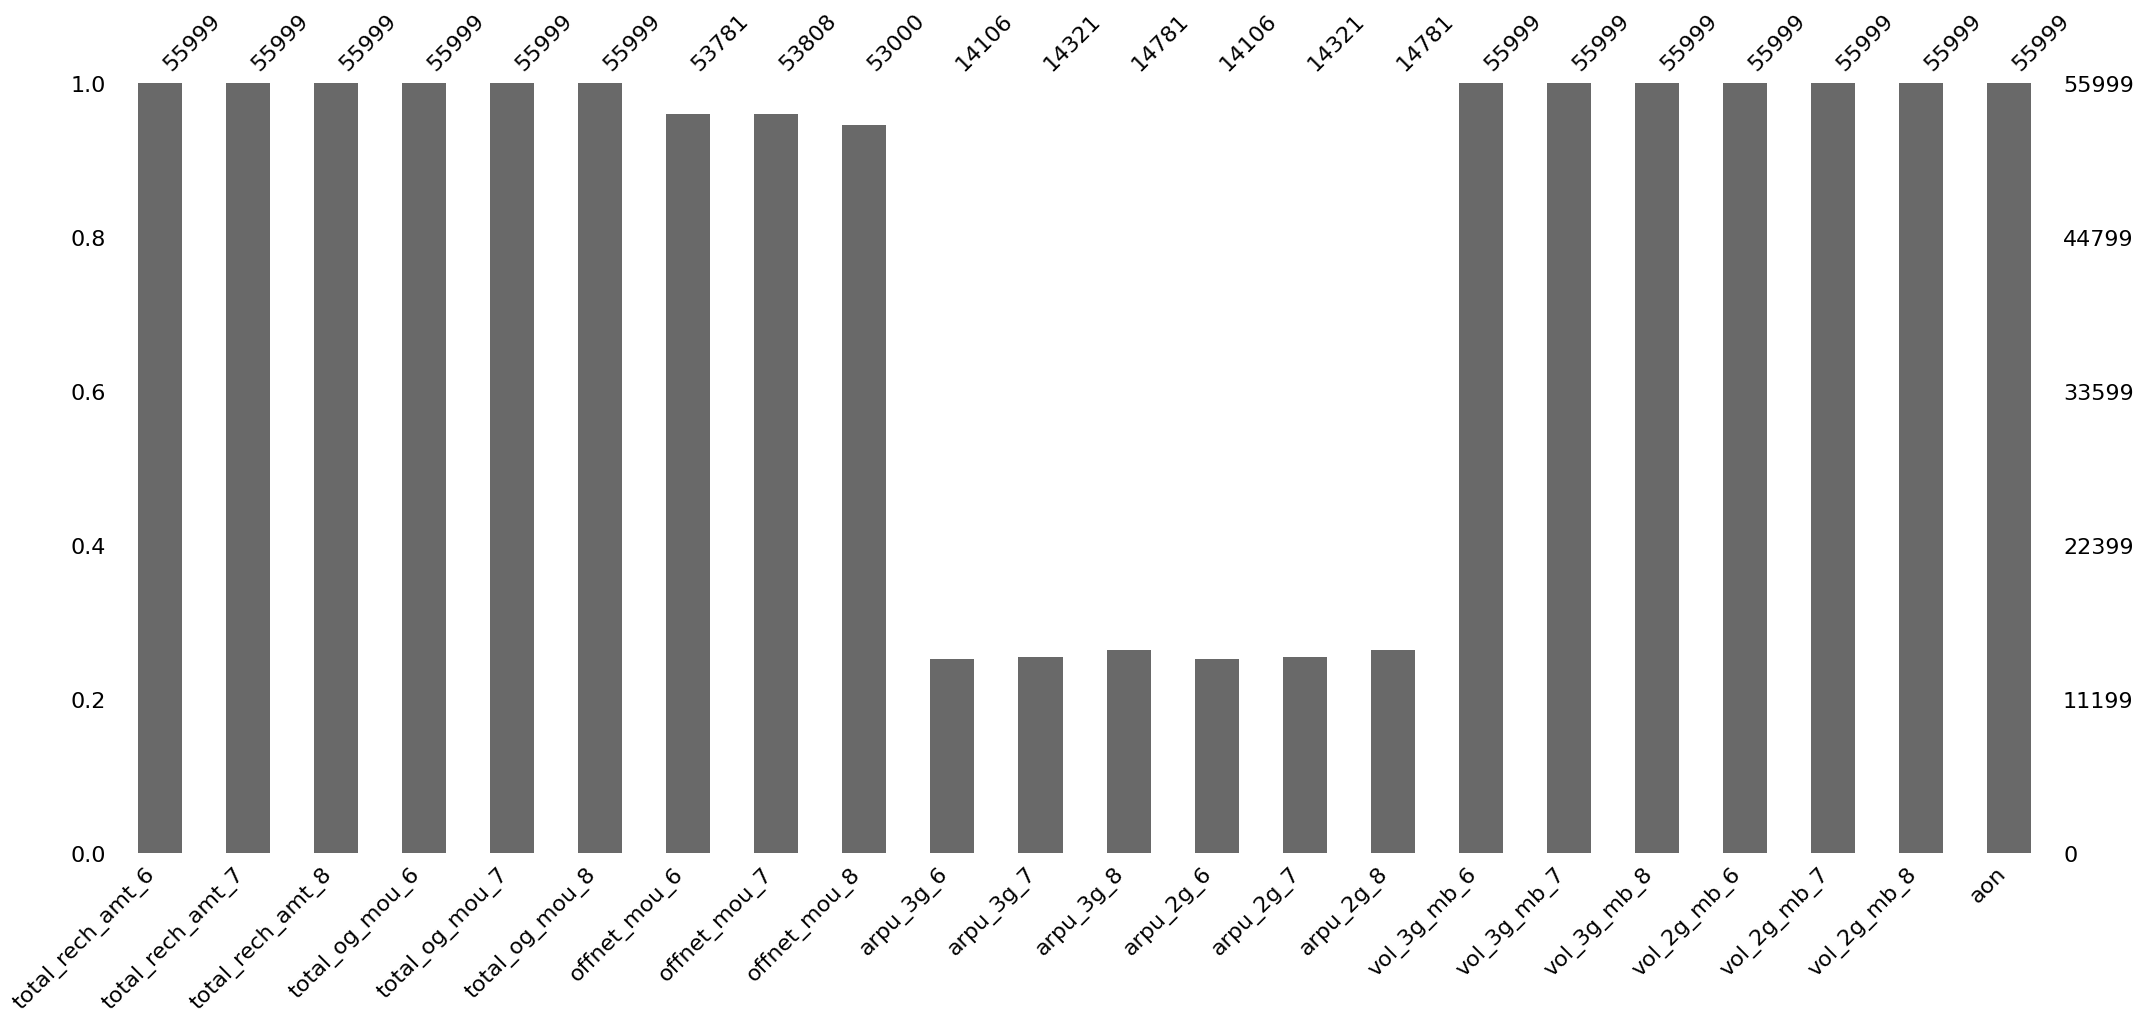

In [450]:
msno.bar(X_train)

<Axes: >

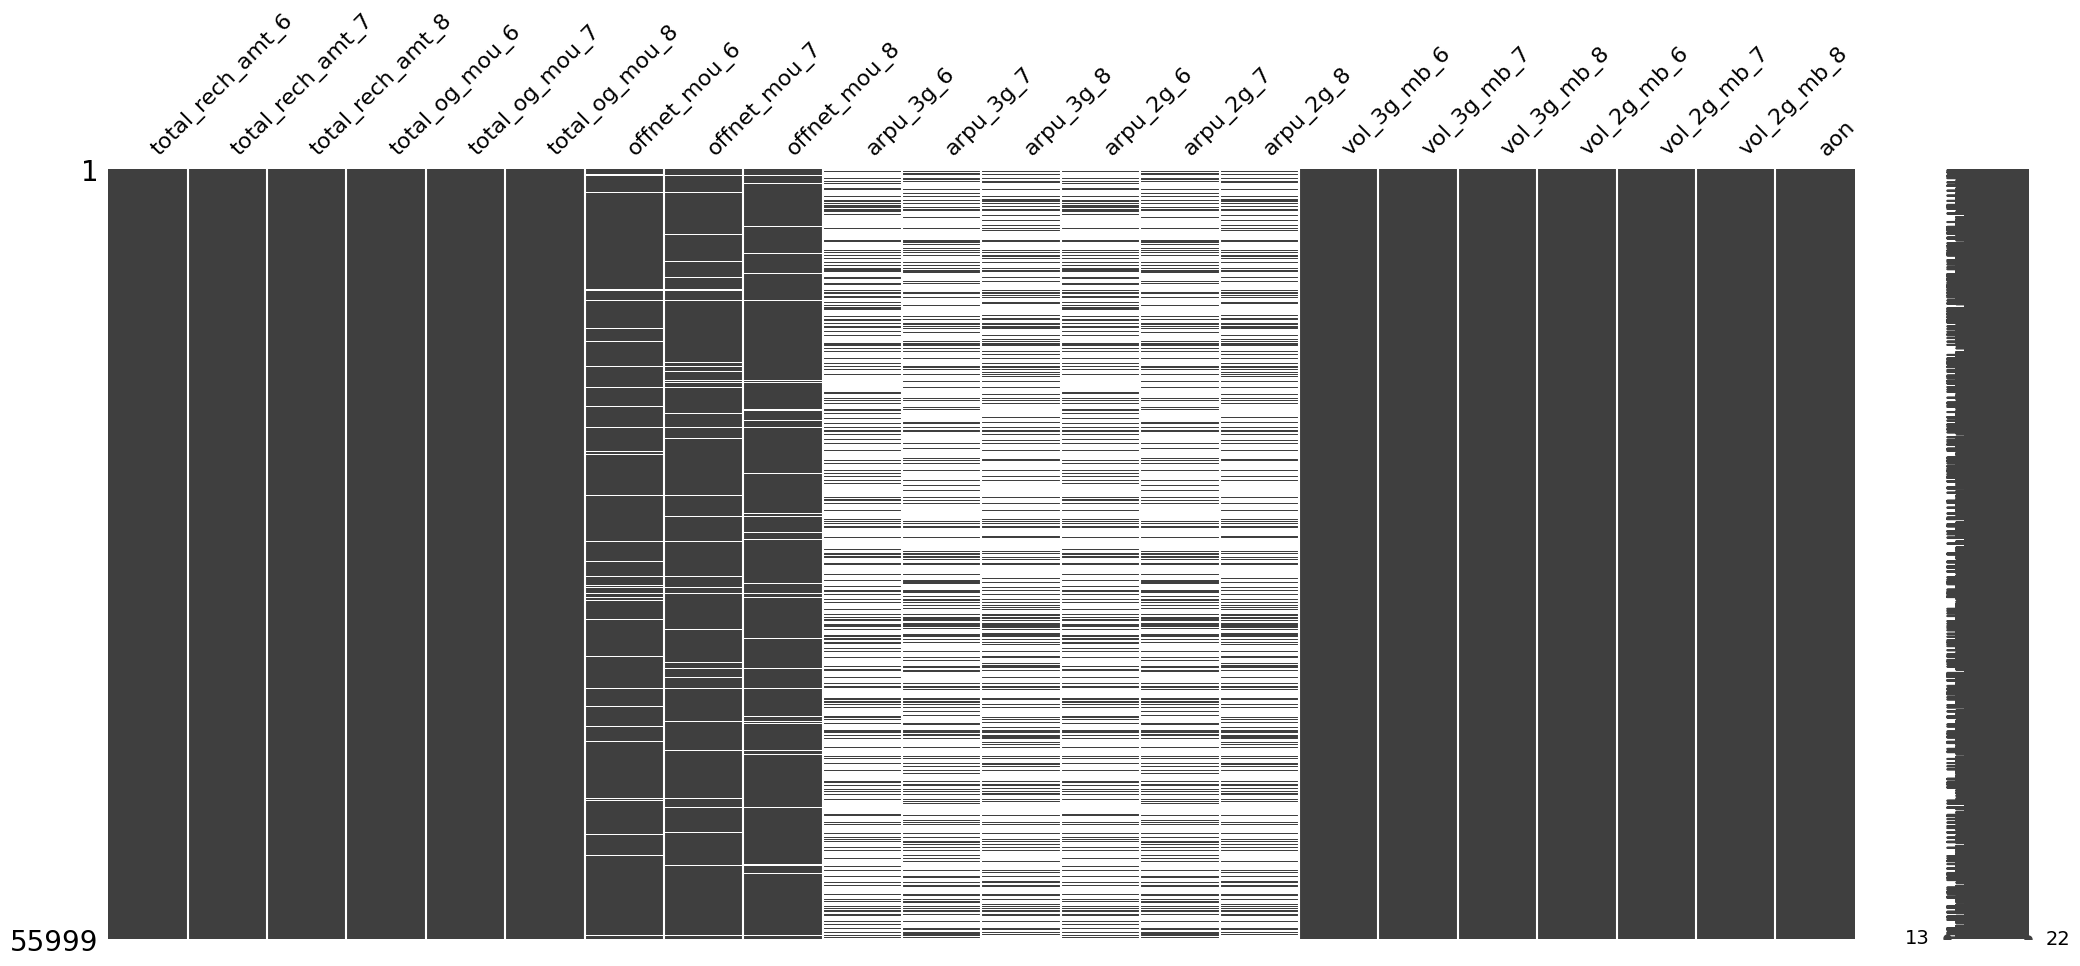

In [451]:
msno.matrix(X_train)

Lets also calculate the % missing data for each column:

In [452]:
missing_data_percent = 100*X_train.isnull().sum()/len(y_train)
missing_data_percent

total_rech_amt_6     0.000000
total_rech_amt_7     0.000000
total_rech_amt_8     0.000000
total_og_mou_6       0.000000
total_og_mou_7       0.000000
total_og_mou_8       0.000000
offnet_mou_6         3.960785
offnet_mou_7         3.912570
offnet_mou_8         5.355453
arpu_3g_6           74.810264
arpu_3g_7           74.426329
arpu_3g_8           73.604886
arpu_2g_6           74.810264
arpu_2g_7           74.426329
arpu_2g_8           73.604886
vol_3g_mb_6          0.000000
vol_3g_mb_7          0.000000
vol_3g_mb_8          0.000000
vol_2g_mb_6          0.000000
vol_2g_mb_7          0.000000
vol_2g_mb_8          0.000000
aon                  0.000000
dtype: float64

We find that a number of columns with more than 70% of its data missing,
- arpu_3g_6            74.760264
- arpu_3g_7            74.388828
- arpu_3g_8            73.595957
- arpu_2g_6            74.760264
- arpu_2g_7            74.388828
- arpu_2g_8            73.595957

These columns will not be very helpful in making a proper model. Hence we shall drop these columns and keep only those columns that have more than 60% data or less than 40% missing data.

In [453]:
# Identify columns that have less than 40% missing data
new_vars = missing_data_percent[missing_data_percent.le(40)].index
new_vars

Index(['total_rech_amt_6', 'total_rech_amt_7', 'total_rech_amt_8',
       'total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8', 'offnet_mou_6',
       'offnet_mou_7', 'offnet_mou_8', 'vol_3g_mb_6', 'vol_3g_mb_7',
       'vol_3g_mb_8', 'vol_2g_mb_6', 'vol_2g_mb_7', 'vol_2g_mb_8', 'aon'],
      dtype='object')

In [454]:
# Pick out only those columns, i.e. the ones selected earlier with less than 40% missing data
X_train_filtered = X_train[new_vars]
X_train_filtered.shape

(55999, 16)

Data imputation on variables

In [455]:
missing_data_percent = X_train_filtered.isnull().any()
#impute_cols = missing_data_percent[missing_data_percent.gt(0)].index
#impute_cols
print("Missing data columns \n ", missing_data_percent)

Missing data columns 
  total_rech_amt_6    False
total_rech_amt_7    False
total_rech_amt_8    False
total_og_mou_6      False
total_og_mou_7      False
total_og_mou_8      False
offnet_mou_6         True
offnet_mou_7         True
offnet_mou_8         True
vol_3g_mb_6         False
vol_3g_mb_7         False
vol_3g_mb_8         False
vol_2g_mb_6         False
vol_2g_mb_7         False
vol_2g_mb_8         False
aon                 False
dtype: bool


In [456]:
# Identify the columns with missing data
impute_cols = missing_data_percent[missing_data_percent.gt(0)].index
print("The columns with missing data are the following, ")
# Print the columns converting a nympy array into a list
for i in impute_cols: #list(impute_cols)
    print (i)

The columns with missing data are the following, 
offnet_mou_6
offnet_mou_7
offnet_mou_8


In [457]:
# We will now impute the missing values with the mean vale of the column
# imputer = SimpleImputer(strategy='constant', fill_value=0)
imputer = SimpleImputer(strategy ='mean', missing_values = np.nan)
X_train_filtered[impute_cols] = imputer.fit_transform(X_train_filtered[impute_cols])

<Axes: >

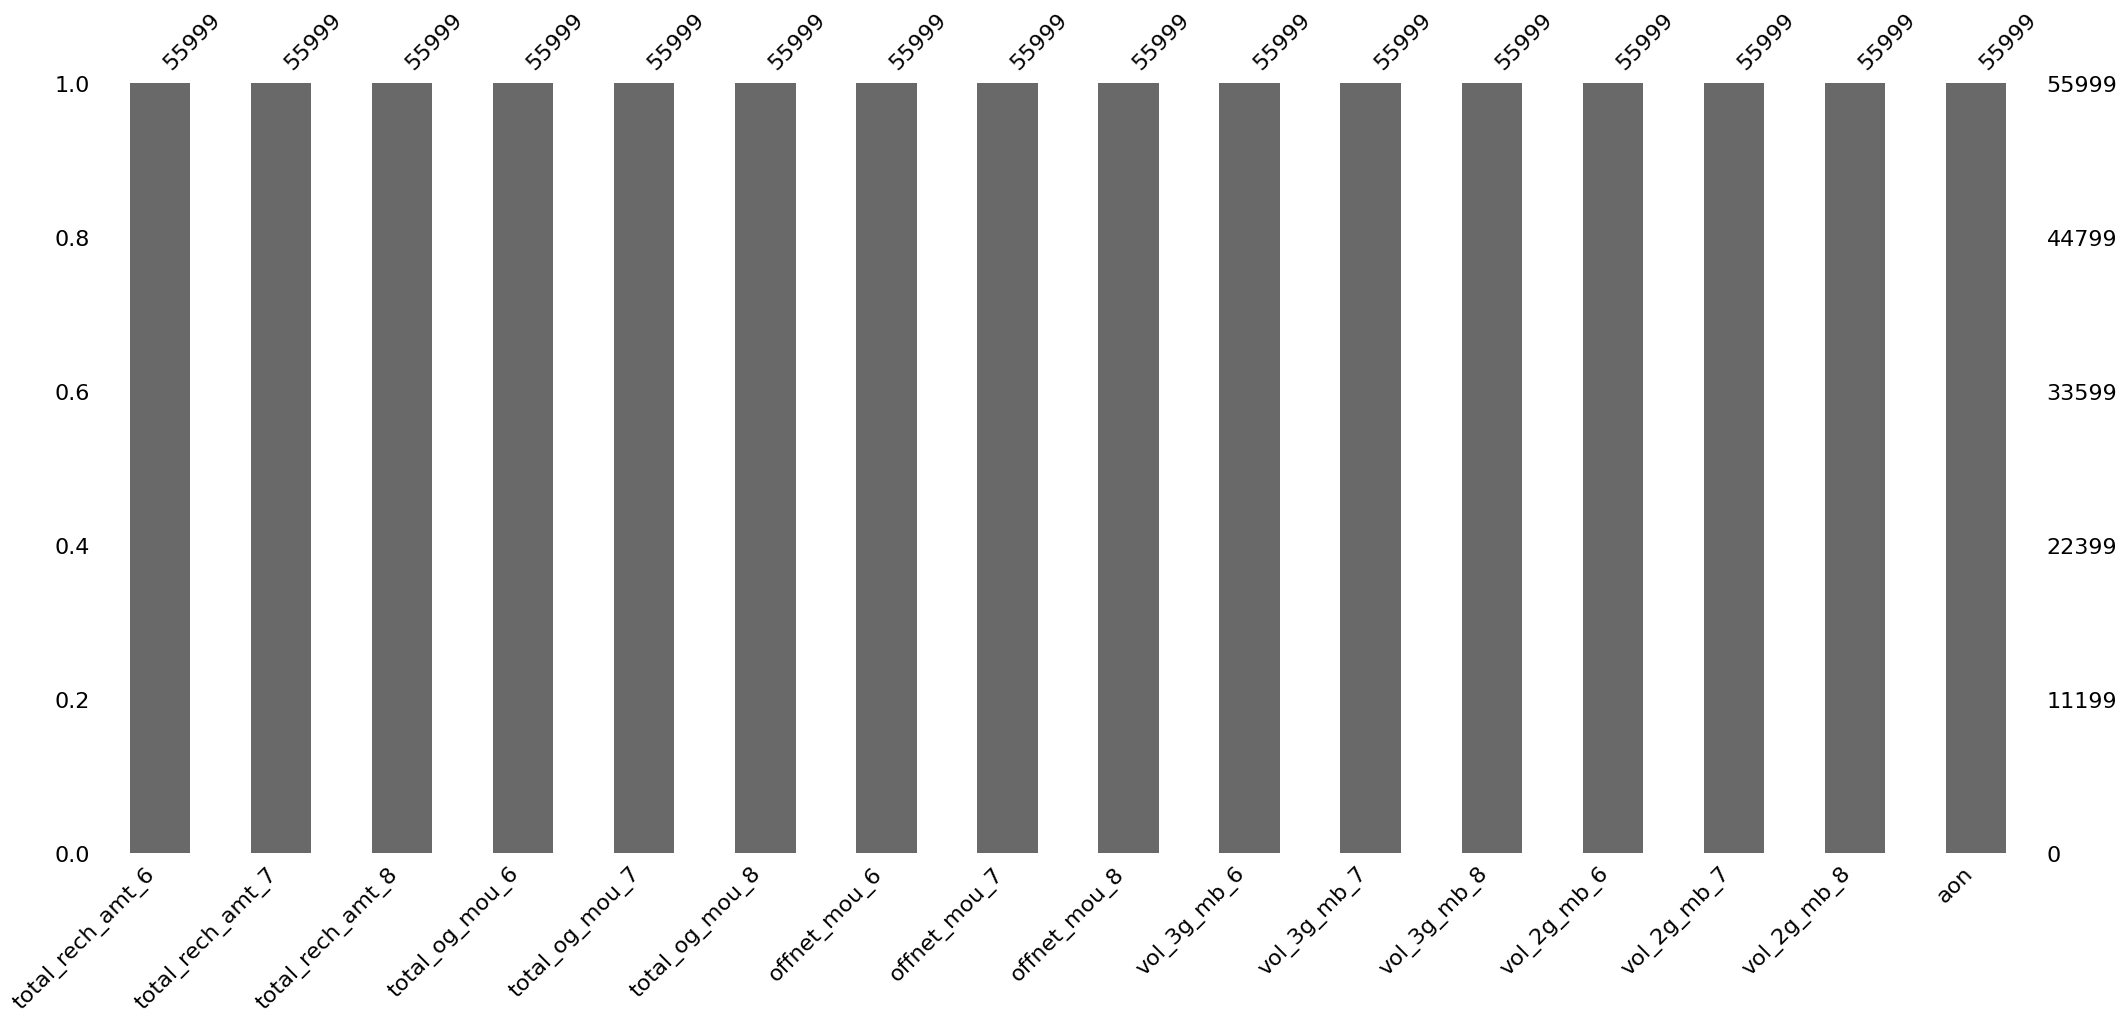

In [458]:
# Check the missing number bar once more to verify that all the missing data have been imputed
msno.bar(X_train_filtered)

In [459]:
X_train_filtered.describe()

,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,aon
count,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000,55999.000000
mean,328.737388,322.782764,324.097948,306.505287,310.324497,304.669236,198.887507,196.844681,196.695663,123.247427,130.254115,136.178305,52.557113,51.673873,50.376591,1219.801014
std,401.766349,417.389894,423.420303,465.955994,480.838006,478.066111,311.111724,316.514955,318.075208,565.311727,561.604411,568.111971,217.279490,213.311950,212.397769,952.337804
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,180.000000
25%,110.000000,100.000000,91.000000,44.980000,42.590000,38.745000,37.140000,33.980000,34.480000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,468.000000
50%,230.000000,220.000000,226.000000,145.280000,141.040000,138.510000,104.010000,98.760000,101.940000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,867.000000
75%,440.000000,430.000000,436.000000,373.025000,377.910000,370.730000,223.310000,217.655000,215.690000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1811.000000
max,35190.000000,40335.000000,45320.000000,8488.360000,8285.640000,14043.060000,8362.360000,7043.980000,14007.340000,45735.400000,28144.120000,30036.060000,10285.900000,7873.550000,8255.670000,4337.000000


# 4. Exploratory Data Analysis & Preprocessing

Lets start by analysing the univariate distributions of each feature.

<Axes: >

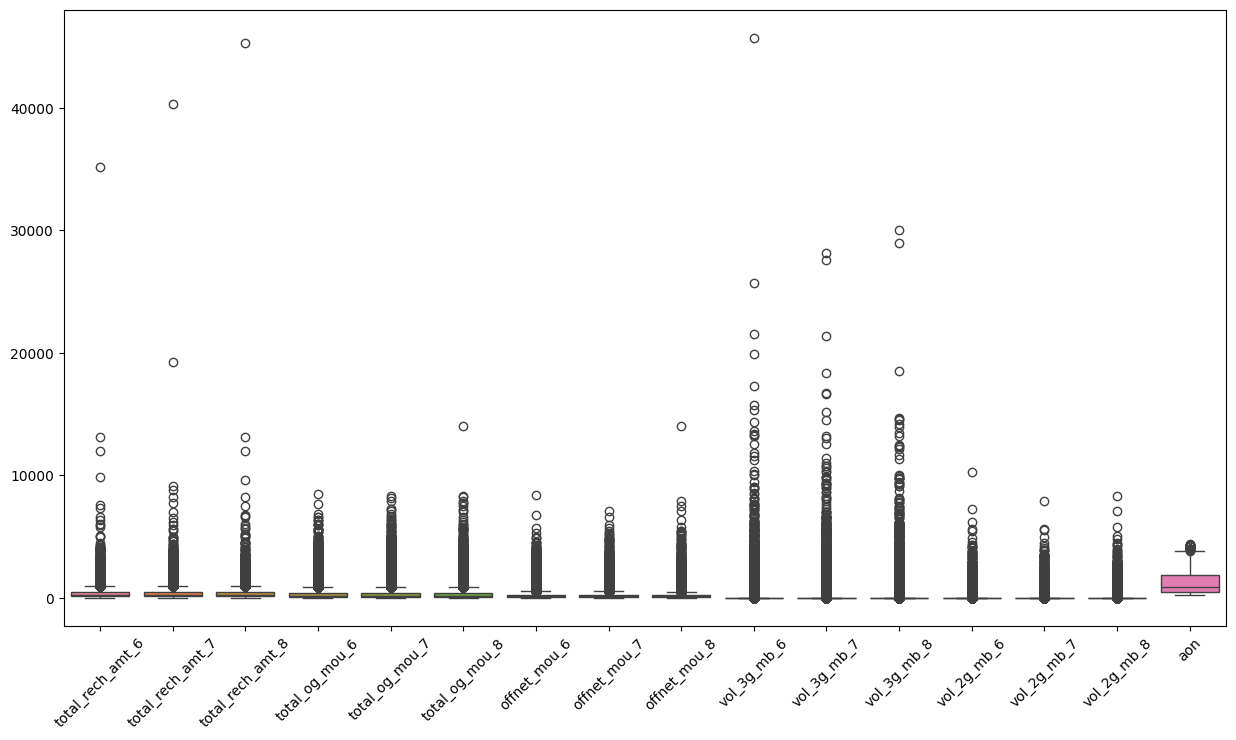

In [460]:
# Box plots to atudy the outliers of each feature
plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
sns.boxplot(data = X_train_filtered)

### 4.1 Handling outliers

The box plots of these features show there a lot of outliers. These can be capped with k-sigma method.

In [461]:
def cap_outliers(array, k=3):
    upper_limit = array.mean() + k*array.std()
    lower_limit = array.mean() - k*array.std()
    array[array<lower_limit] = lower_limit
    array[array>upper_limit] = upper_limit
    return array

<Axes: >

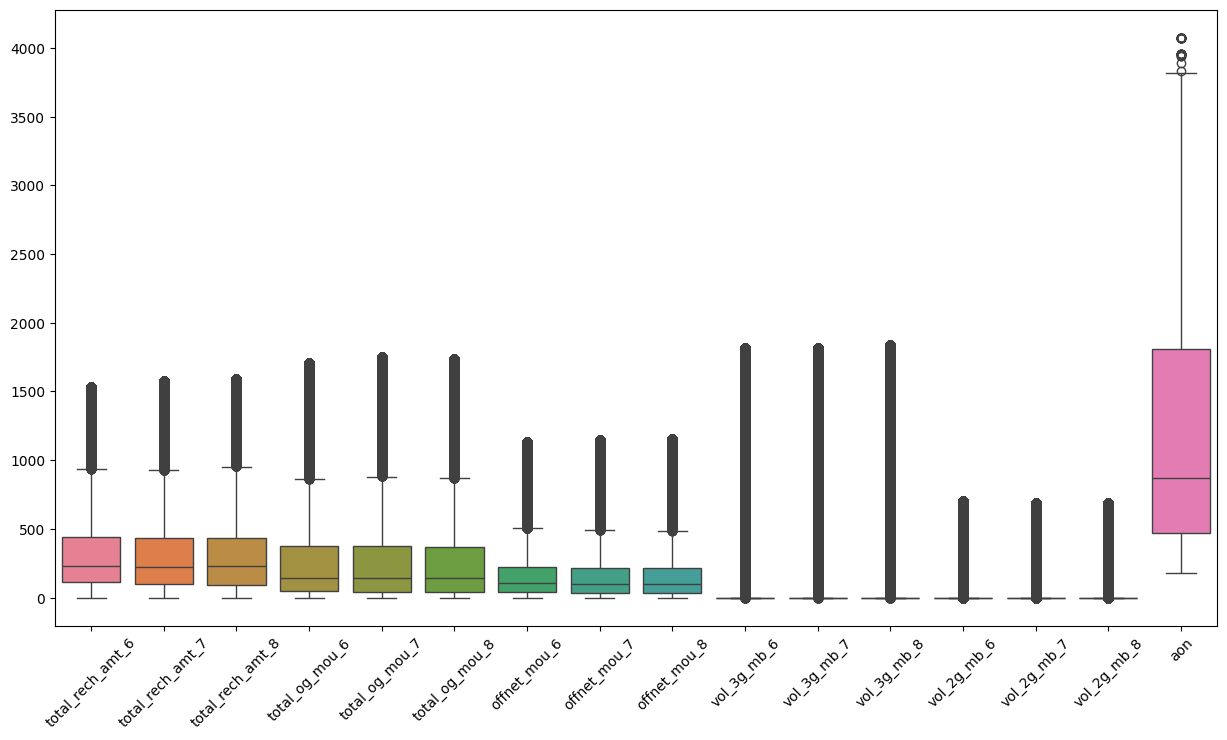

In [462]:
X_train_filtered1 = X_train_filtered.apply(cap_outliers, axis=0)

plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
sns.boxplot(data = X_train_filtered1)

### 4.2 Feature scaling

Lets also scale the features by scaling them with Standard scaler

In [463]:
# Scale the features using Standard scaler
scale = StandardScaler()
X_train_filtered2 = scale.fit_transform(X_train_filtered1)

<Axes: >

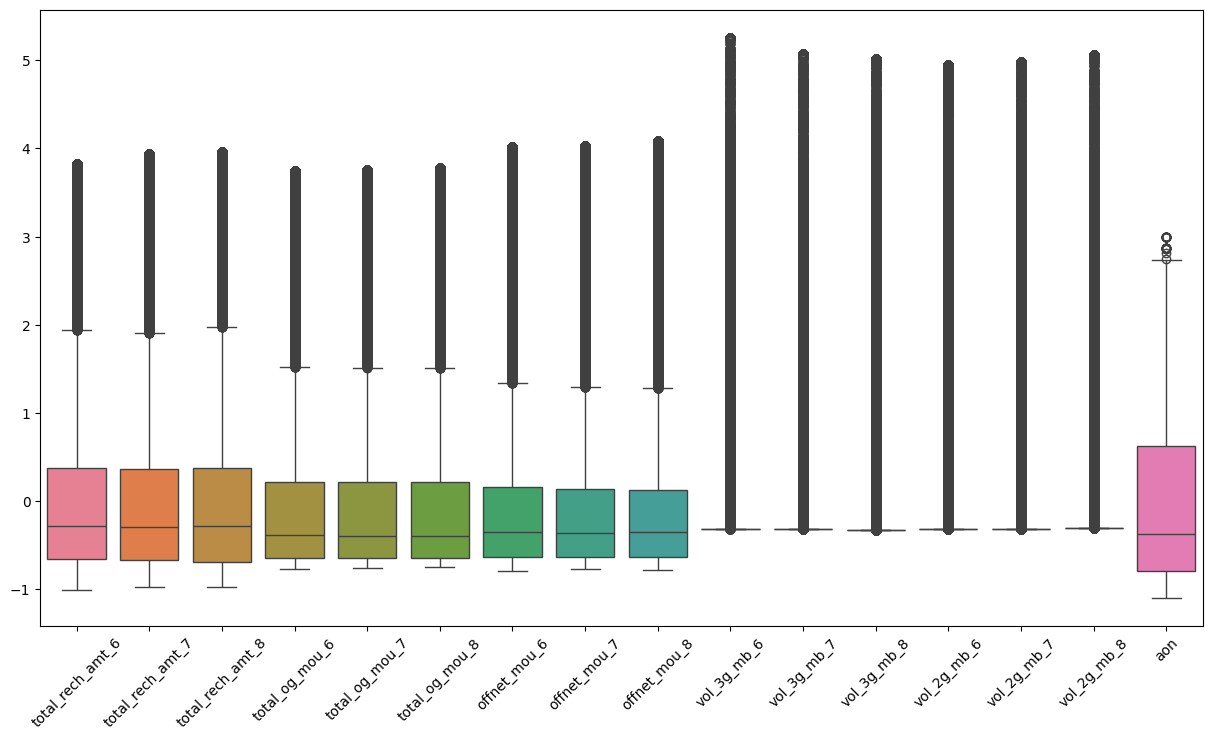

In [464]:
plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
sns.boxplot(data = pd.DataFrame(X_train_filtered2, columns=new_vars))


We'll plot the correlations for each feature for bivariate analysis.

<Axes: >

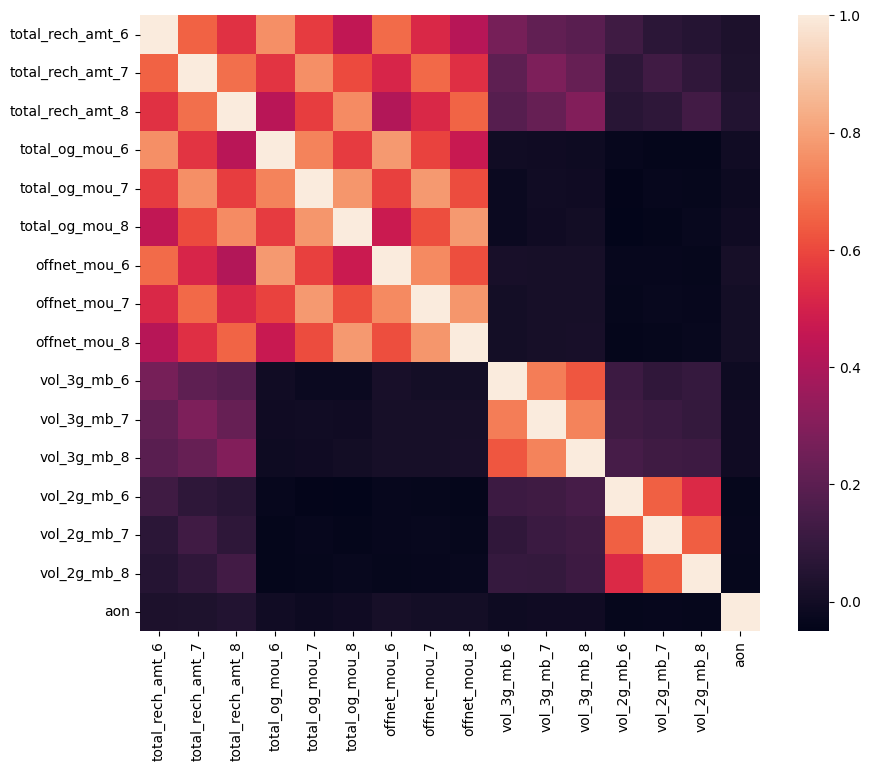

In [465]:
# Produce a heat map of the features to identify correlation between them
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X_train_filtered2, columns=new_vars).corr())

We don't find significant high correlations between the features

<Axes: ylabel='Count'>

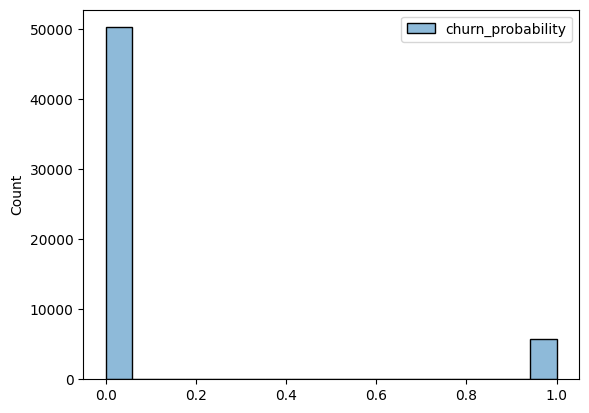

In [466]:
#Distribution for the churn probability
sns.histplot(y_train)

The churn data is significantly lower than the non churn data. This looks like because of the skew the model that we will build will tilt towards non churn. Let's study it a little more closely. 

In [467]:
#missing_data_percent = 100*X_train.isnull().sum()/len(y_train)
# missing_data_percent
churn_prob_percent = 100*y_train[y_train["churn_probability"] == 1].count()/len(y_train)
print("The percentage of churn probability within the data is, ", churn_prob_percent)

The percentage of churn probability within the data is,  churn_probability    10.187682
dtype: float64


# 5. Feature engineering and selection

Let's understand feature importances for raw features as well as components to decide top features for modelling.

In [468]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf.fit(X_train_filtered2, y_train)

RandomForestClassifier(n_jobs=-1)

In [469]:
feature_importances = pd.DataFrame({'col':new_vars, 'importance':rf.feature_importances_})

<BarContainer object of 16 artists>

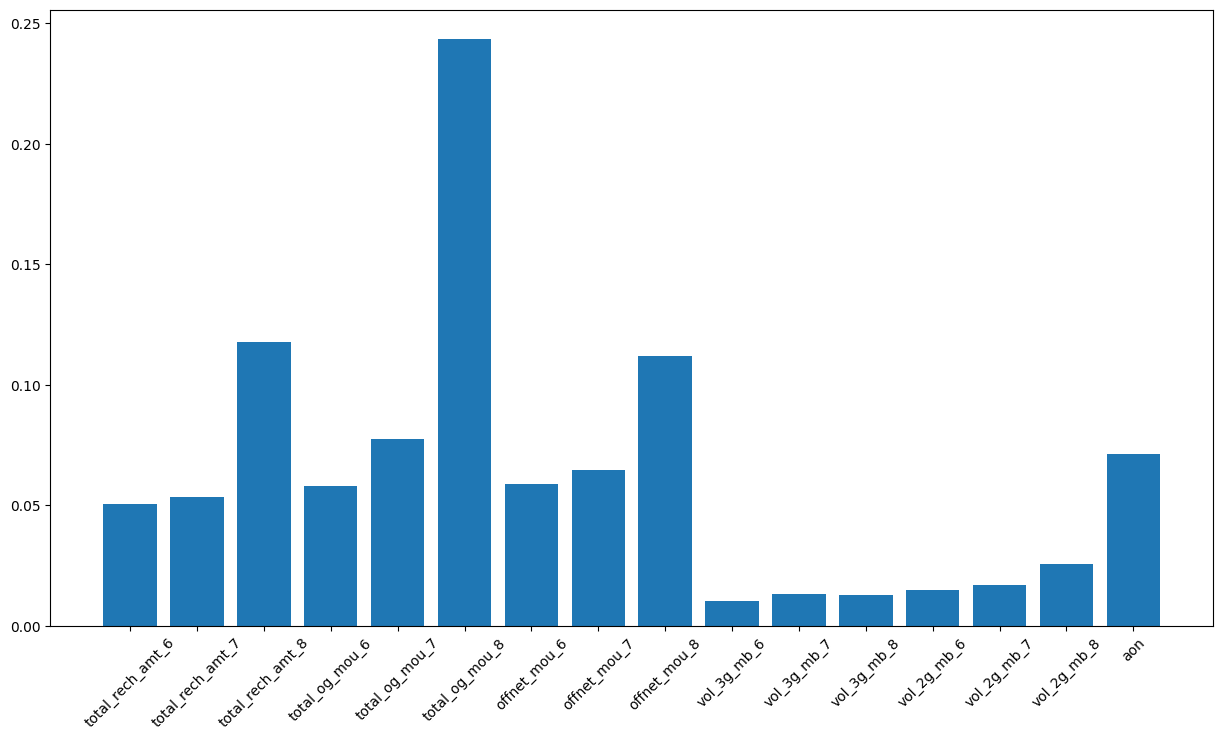

In [470]:
# Let's plot the features by their importance
plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
plt.bar(feature_importances['col'], feature_importances['importance'])

### We will use PCA to identify the features by importance

<Axes: >

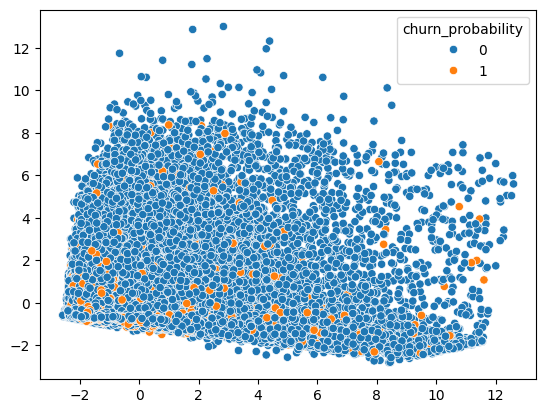

In [471]:
pca = PCA()
pca_components = pca.fit_transform(X_train_filtered2)

# Plot the elements in pca and mark the ones that have churned
sns.scatterplot(x=pca_components[:,0], y=pca_components[:,1], hue=y_train["churn_probability"])

<Axes: >

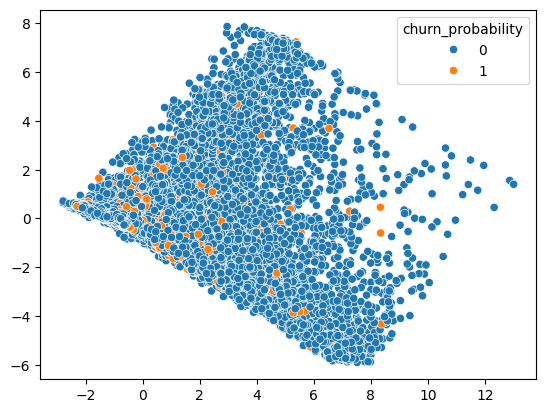

In [472]:
sns.scatterplot(x=pca_components[:,1], y=pca_components[:,2], hue=y_train["churn_probability"])

Let's also check which of the components have high feature importances towards the end goal of churn prediction.

<BarContainer object of 16 artists>

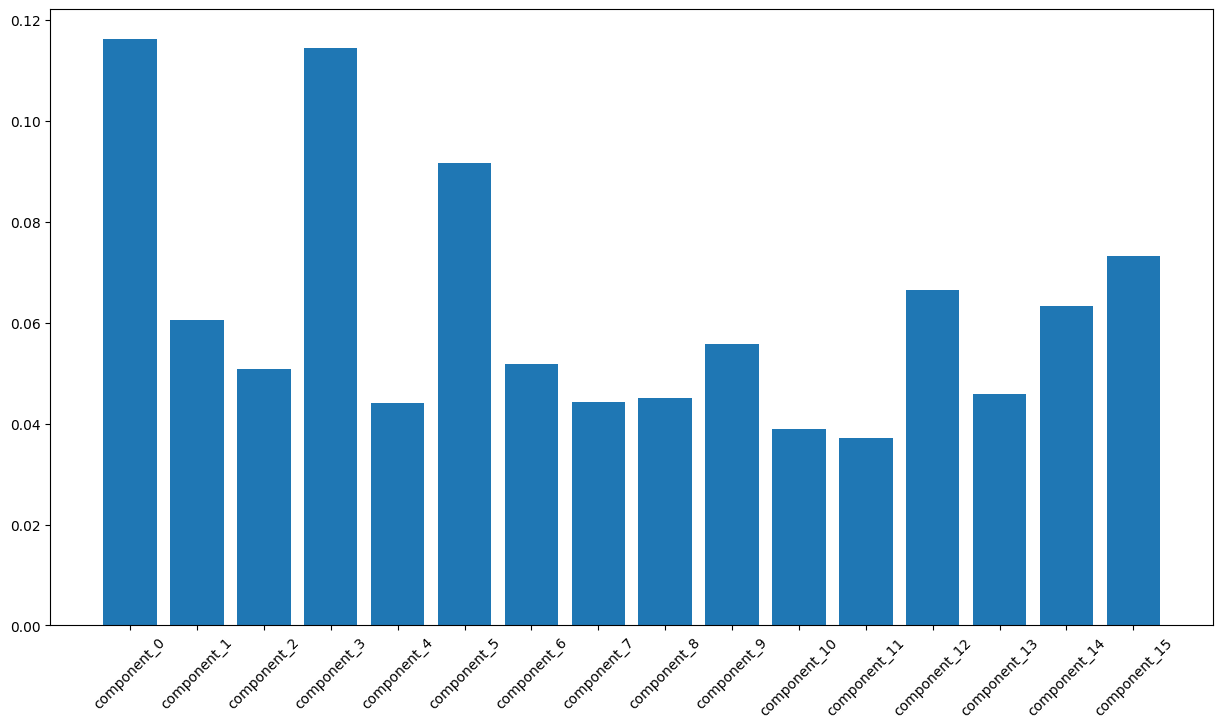

In [473]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
rf.fit(pca_components, y_train)

feature_importances = pd.DataFrame({'col':['component_'+str(i) for i in range(16)], 
                                    'importance':rf.feature_importances_})

plt.figure(figsize=(15,8))
plt.xticks(rotation=45)
plt.bar(feature_importances['col'], feature_importances['importance'])

# 6. Model building

Let's build a quick model with logistic regression and the first 2 PCA components.

In [474]:
lr = LogisticRegression(max_iter=1000, tol=0.001, solver='sag')
lr.fit(pca_components[:,:2], y_train)

LogisticRegression(max_iter=1000, solver='sag', tol=0.001)

In [475]:
lr.score(pca_components[:,:2], y_train)

0.8981231807710852

The model has 89.8% accuracy, but let's build a pipeline to fit and score the model faster.

The steps of this pipeline would be the following, but this is only one type of pipeline -
1. Imputation
2. Scaling
3. PCA
4. Classification model

In [476]:
imputer = SimpleImputer(strategy='constant', fill_value=0)
#imputer = SimpleImputer(strategy ='median', missing_values = np.nan)
scale = StandardScaler()
pca = PCA(n_components=10)
lr = LogisticRegression(max_iter=1000, tol=0.001)

In [477]:
pipe = Pipeline(steps = [('imputation',imputer),
                         ('scaling',scale),
                         ('pca',pca),
                         ('model',lr)])

In [478]:
pipe.fit(X_train[new_vars], y_train)

Pipeline(steps=[('imputation',
                 SimpleImputer(fill_value=0, strategy='constant')),
                ('scaling', StandardScaler()), ('pca', PCA(n_components=10)),
                ('model', LogisticRegression(max_iter=1000, tol=0.001))])

In [479]:
train_score = pipe.score(X_train[new_vars], y_train)
print("Training accuracy:", train_score)

Training accuracy: 0.8996232075572778


In [480]:
test_score = pipe.score(X_test[new_vars], y_test)
print("Test accuracy:", test_score)

Test accuracy: 0.901


Let's make a confusion matrix to analyze how each class is being predicted by the model.

In [481]:
confusion_matrix(y_train, pipe.predict(X_train[new_vars]))

array([[50020,   274],
       [ 5347,   358]], dtype=int64)

In [482]:
confusion_matrix(y_test, pipe.predict(X_test[new_vars]))

array([[12507,    66],
       [ 1320,   107]], dtype=int64)

We can see a high amount of type 2 error. Due to class imbalance, the model is clearly trying to predict majority of the cases as class 0. 

In [483]:
precision_score(y_test, pipe.predict(X_test[new_vars]))

0.6184971098265896

In [484]:
recall_score(y_test, pipe.predict(X_test[new_vars]))

0.07498248072880168

### Ensemble method - Random Forest

We have seen how accurate the model is with a Logistic Regression pipeline. We shall now run a Random Forest using Grid Search to identify the best model and compare the models to decide which model to retain for the final prediction.

In [485]:
# Create base model
rfc  = RandomForestClassifier(random_state=42)  

# Random forest hyperparameter tuning parameters
params = {
    'max_depth': range(5,10,5),
    'min_samples_leaf': range(50, 150, 50),
    'min_samples_split': range(50, 150, 50),
    'n_estimators': [100,200,300], 
    'max_features': [10, 20]
}

# Cross validation
folds = 5

In [486]:
# Instantiate the grid search model
model_cv = GridSearchCV(estimator = rfc, 
                            param_grid = params, 
                            cv = folds, 
                            n_jobs = -1, 
                            verbose = 1)

In [487]:
model_cv.fit(X_train[new_vars], y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(5, 10, 5), 'max_features': [10, 20],
                         'min_samples_leaf': range(50, 150, 50),
                         'min_samples_split': range(50, 150, 50),
                         'n_estimators': [100, 200, 300]},
             verbose=1)

In [488]:
# best hyper parameters
print("Tuned Random Forest Parameters: ", format(model_cv.best_params_))
print("Best score is ", format(model_cv.best_score_))

Tuned Random Forest Parameters:  {'max_depth': 5, 'max_features': 20, 'min_samples_leaf': 50, 'min_samples_split': 50, 'n_estimators': 100}
Best score is  0.9387488455601902


In [489]:
# Build new  model with best hyperparameters
rfc_best = RandomForestClassifier(max_depth=model_cv.best_params_["max_depth"], 
                                      max_features=model_cv.best_params_["max_features"], 
                                      min_samples_leaf=model_cv.best_params_["min_samples_leaf"],
                                      min_samples_split=model_cv.best_params_["min_samples_split"], 
                                      n_estimators=model_cv.best_params_["n_estimators"], 
                                      random_state=42)

In [490]:
# Build new  model with best hyperparameters

rfc_best.fit(X_train[new_vars], y_train)

RandomForestClassifier(max_depth=5, max_features=20, min_samples_leaf=50,
                       min_samples_split=50, random_state=42)

In [491]:
# Predict on Train and Test Data
y_train_pred = rfc_best.predict(X_train[new_vars])
y_test_pred = rfc_best.predict(X_test[new_vars])


In [492]:
# Classification report on train and test
print("Classification report on train data")
print(classification_report(y_train,y_train_pred))
print("Classification report on test data")
print(classification_report(y_test,y_test_pred))

Classification report on train data
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     50294
           1       0.78      0.56      0.65      5705

    accuracy                           0.94     55999
   macro avg       0.87      0.77      0.81     55999
weighted avg       0.93      0.94      0.93     55999

Classification report on test data
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     12573
           1       0.78      0.54      0.64      1427

    accuracy                           0.94     14000
   macro avg       0.86      0.76      0.80     14000
weighted avg       0.93      0.94      0.93     14000



In [501]:
# Accuracy score on train and test data
print("Accuracy score on train data")
print(accuracy_score(y_train,y_train_pred))
print("Accuracy score on test data")
print(accuracy_score(y_test,y_test_pred))

Accuracy score on train data
0.9391596278504973
Accuracy score on test data
0.9372142857142857


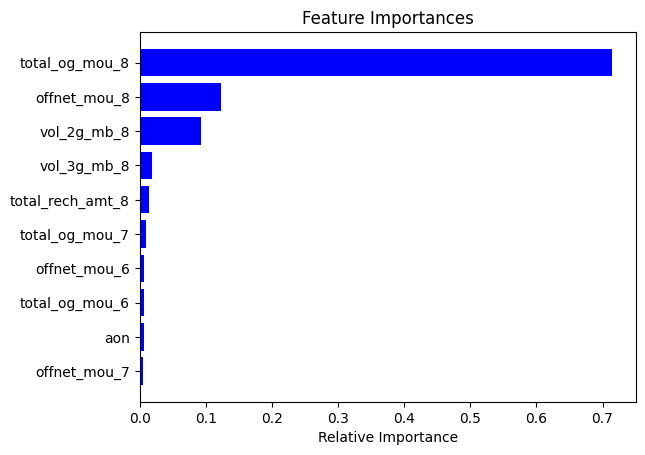

In [502]:
# Top 10 predictor variables
feature_importances = rfc_best.feature_importances_
features = X_train[new_vars].columns
importances = feature_importances
indices = np.argsort(importances)[-10:]
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## <span style="color:yellow"> Conclusion on models </span>
---
Table to compare accuracies of both models

| Model algorithm | Data Section | Accuracy |
| :--- | :----: | :----: |
| Logistic Regression | Train data | 0.8999 |
| Logistic Regression | Test data | 0.8995 |
| Random Forest | Train data | 0.9389 |
| Random Forest | Test data | 0.9387 |


We have pitted 2 types of models, Linear Regression and Random Forest against each other and we found that the best model is a **Random Forest model** with the following hyper parameters:
- max_depth=5
- max_features=10
- min_samples_leaf=50
- min_samples_split=50
- n_estimators=200
- random_state=42

Hence we shall use the model built with Random Forest for our final prediction

---


# 7. Creating submission file

For submission, we need to make sure that the format is exactly the same as the sample.csv file. It contains 2 columns, id and churn_probability

In [503]:
sample.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,0
3,70002,0
4,70003,0


The submission file should contain churn_probability values that have to be predicted for the unseen data provided (test.csv)

In [504]:
unseen.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,69999,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,91.882,65.330,...,0,0,NaN,NaN,NaN,1692,0.00,0.00,0.00,0
1,70000,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,414.168,515.568,...,0,0,NaN,NaN,NaN,2533,0.00,0.00,0.00,0
2,70001,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,329.844,434.884,...,0,0,NaN,NaN,NaN,277,525.61,758.41,241.84,1
3,70002,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,43.550,171.390,...,0,0,NaN,NaN,NaN,1244,0.00,0.00,0.00,0
4,70003,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,306.854,406.289,...,0,0,NaN,NaN,NaN,462,0.00,0.00,0.00,0


Lets first select the columns that we want to work with (or create them, if you have done any feature engineering)

In [505]:
submission_data = unseen.set_index('id')[new_vars]
submission_data.shape

(30000, 16)

Next, lets create a new column in the unseen dataset called churn_probability and use the model pipeline to predict the probabilities for this data

In [506]:
# Predict the churn probability from the best Random Forest model
#unseen['churn_probability'] = pipe.predict(submission_data)
unseen['churn_probability'] = rfc_best.predict(submission_data)

output = unseen[['id','churn_probability']]
output.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,1
3,70002,0
4,70003,0


Finally, lets create a csv file out of this dataset, ensuring to set index=False to avoid an addition column in the csv.

In [507]:
output.to_csv('submission_abhijit_ghouse_9Jun24.csv',index=False)

The generated file, <span style="color:yellow">__submission_abhijit_ghouse_9Jun24.csv__ </span>will be submitted to Kaggle.